In [1]:
import numpy as np
import lib_debug

%load_ext autoreload
%autoreload 2

In [2]:
# test of test function
dims = 30
x = np.full(dims, 0)
print(lib_debug.ackley_nd(x))
print(lib_debug.griewank_nd(x))

[4.4408921e-16]
[0.]


In [3]:
lib_debug.ackley_2d(np.array([0.0858384278227287,0.0443568618881667]))

array([0.50605682])

In [4]:
def debug_ackley(params, n_params):    
    x = np.array(params)
    n = float(n_params)

    arg1 = -0.2 * np.sqrt((1.0/n) * np.sum(x**2))
    arg2 = (1.0/n) * np.sum(np.cos(2. * np.pi * x))
    
    y = -20. * np.exp(arg1) - np.exp(arg2) + 20. + np.e

    print(y)

In [5]:
debug_ackley([0.0858384278227287,0.0443568618881667], 2)

0.5060568244289532


--- Strategy Selected: LCB ---
--- Starting Optimization Loop (30 iterations) ---
Iter  | Best y     | New y      | New x (approx)
--------------------------------------------------
1     | -0.870369   | -0.575861   | [0.63]
2     | -0.870369   | 0.451461   | [1.00]
3     | -0.936148   | -0.936148   | [0.69]
4     | -0.936148   | -0.851816   | [0.69]
5     | -0.936148   | -0.884685   | [0.69]
6     | -0.936148   | -0.855560   | [0.69]
7     | -0.936148   | -0.852019   | [0.69]
8     | -0.936148   | -0.892551   | [0.69]
9     | -0.936148   | -0.876137   | [0.69]
10    | -0.936148   | -0.916419   | [0.69]
11    | -0.956217   | -0.956217   | [0.69]
12    | -0.956217   | -0.846719   | [0.69]
13    | -0.956217   | -0.937964   | [0.69]
14    | -0.956217   | -0.919160   | [0.70]
15    | -0.956217   | -0.902648   | [0.70]
16    | -0.956217   | -0.889178   | [0.70]
17    | -0.956217   | -0.897384   | [0.69]
18    | -0.956217   | -0.822169   | [0.70]
19    | -0.956217   | -0.810421   | [0.69]
20

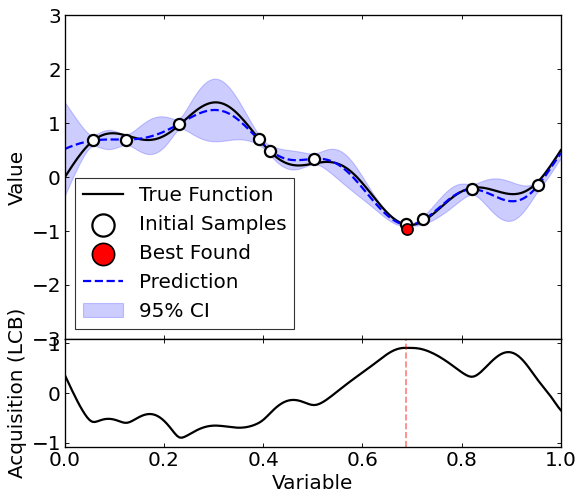

--------------------------------------------------
Optimization Finished using LCB.
Global Best Found: y = -0.956217


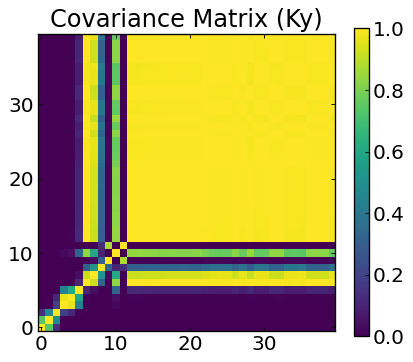

In [6]:
# -------------------- 1. Setup & Aliasing --------------------
kernel = lib_debug.rbf_kernel

# -------------------- 2. Settings --------------------
# Hyperparameters
gamma = 65.0
noise_std = 0.05
noise_var = noise_std ** 2

# Domain settings
dims = 1
lower_bounds = [0.0]
upper_bounds = [1.0]

# Optimization Loop Settings
n_init = 10
n_iter = 30
xi = 0.01

# Grid for plotting ONLY (No longer used for search loop)
X_grid = np.linspace(0, 1, 200)[:, None]

# --- Acquisition Function Selection ---
STRATEGY = "LCB"  # Options: "EI" or "LCB"

if STRATEGY == "EI":
    acq_func = lib_debug.expected_improvement
    acq_params = {'xi': 0.01}
elif STRATEGY == "LCB":
    acq_func = lib_debug.lower_confidence_bound
    acq_params = {'kappa': 2.0}
else:
    raise ValueError("Unknown strategy")

print(f"--- Strategy Selected: {STRATEGY} ---")

# -------------------- 3. Initialization --------------------
# Generate samples and observations
X_train = lib_debug.LHSsampler(dims, n_init, lower_bounds, upper_bounds)
X_train = X_train[np.argsort(X_train[:, 0])]
y_train = lib_debug.test_1D(X_train).reshape(-1, 1) + np.random.normal(0, noise_std, (len(X_train), 1))

# Keep copy for plotting
X_init_plot = X_train.copy()
y_init_plot = y_train.copy()

# -------------------- 4. Bayesian Optimization Loop --------------------
print(f"--- Starting Optimization Loop ({n_iter} iterations) ---")
print(f"{'Iter':<5} | {'Best y':<10} | {'New y':<10} | {'New x (approx)'}")
print("-" * 50)

for i in range(n_iter):
    
    # 1. Fit GP (Calculate Ky_inv)
    Ky_inv = lib_debug.fit_gp(kernel, X_train, gamma, noise_var)

    # 2. Find Next Point (Continuous Optimization instead of Grid Search)
    x_new, _ = lib_debug.optimize_acquisition(
        kernel, 
        acq_func, 
        X_train, y_train, Ky_inv, gamma, 
        lower_bounds, upper_bounds, acq_params
    )
    
    # 3. Evaluate True Function
    # x_new comes out as (dims,), need reshape for evaluation
    y_new = lib_debug.test_1D(x_new.reshape(1, -1)) + np.random.normal(0, noise_std, (1, 1))

    # 4. Update Data
    X_train = np.vstack([X_train, x_new])
    y_train = np.vstack([y_train, y_new])
    
    # Log
    current_best = np.min(y_train)
    print(f"{i+1:<5} | {current_best:.6f}   | {y_new.item():.6f}   | [{x_new[0]:.2f}]")


# -------------------- 5. Final Calculation & Visualization --------------------
# Re-fit GP with all data
Ky_inv = lib_debug.fit_gp(kernel, X_train, gamma, noise_var)

# Get predictions and acquisition values for plotting
# (Here we still use X_grid to draw the curves)
mu_list = []
sigma_list = []
acq_final_list = []

for x in X_grid:
    m, s = lib_debug.get_posterior(kernel, x, X_train, y_train, Ky_inv, gamma)
    mu_list.append(m)
    sigma_list.append(s)
    acq_final_list.append(acq_func(kernel, x, X_train, y_train, Ky_inv, gamma, **acq_params))

mu_post = np.array(mu_list)
s_post = np.array(sigma_list)
acq_final = np.array(acq_final_list)

# Identify Best Point
best_idx_final = np.argmin(y_train)
best_x = X_train[best_idx_final]
best_y = y_train[best_idx_final]

# Visualization
lib_debug.plot_gp_results(
    X_grid=X_grid,
    true_func=lib_debug.test_1D,
    X_init=X_init_plot,
    y_init=y_init_plot,
    best_x=best_x,
    best_y=best_y,
    mu=mu_post,
    sigma=s_post,
    acq_values=acq_final,
    strategy_name=STRATEGY
)

print("-" * 50)
print(f"Optimization Finished using {STRATEGY}.")
print(f"Global Best Found: y = {y_train[best_idx_final].item():.6f}")

# Final Covariance Plot
K_final = kernel(X_train, X_train, gamma)
lib_debug.plot_covariance_matrix(K_final)

--- Strategy Selected: EI ---
--- Starting Optimization Loop (100 iterations) ---
Iter  | Best y     | New y      | Gamma    | x_acq    | New x
---------------------------------------------------------------------------
1     | 0.913730   | 0.913730   | 1.4717   | 1.7425   | [0.01, -0.15]
2     | 0.892498   | 0.892498   | 1.4612   | 0.0208   | [0.09, -0.11]
3     | 0.892498   | 2.536367   | 1.4564   | 0.0000   | [0.28, 0.19]
4     | 0.892498   | 2.406548   | 1.6131   | 0.2576   | [0.16, -0.28]
5     | 0.892498   | 6.425876   | 2.3515   | 0.1637   | [2.00, 0.33]
6     | 0.892498   | 5.855804   | 2.3114   | 0.1196   | [-1.12, -2.00]
7     | 0.892498   | 4.472899   | 2.2375   | 0.0000   | [-0.94, -0.45]
8     | 0.892498   | 6.773750   | 2.2592   | 0.0010   | [-2.00, 0.56]
9     | 0.892498   | 6.593599   | 2.2149   | 0.0011   | [-2.00, 2.00]
10    | 0.892498   | 5.475672   | 2.1893   | 0.0000   | [-1.30, 1.02]
11    | 0.892498   | 5.565093   | 2.2228   | 0.0000   | [1.24, 0.61]
12    | 0.8

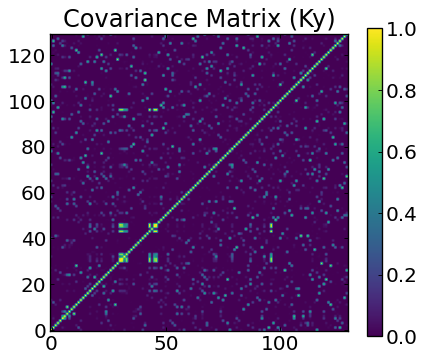

In [7]:
import numpy as np
from scipy.optimize import minimize
import lib_debug

# -------------------- 1. Setup & Aliasing --------------------
kernel = lib_debug.rbf_kernel

# -------------------- 2. Settings --------------------
dims = 2
lower_bounds = [-32, -32]
lower_bounds = [-2, -2]
upper_bounds = [32, 32]
upper_bounds = [2, 2]

# Initial Gamma
current_gamma = 1.0
noise_std = 0.0
noise_var = noise_std ** 2

n_init = 30
n_iter = 100

# Strategy Selection
STRATEGY = "EI" 
if STRATEGY == "EI":
    acq_func = lib_debug.expected_improvement
    acq_params = {'xi': 0.01}
elif STRATEGY == "LCB":
    acq_func = lib_debug.lower_confidence_bound
    acq_params = {'kappa': 2.0}
else:
    raise ValueError("Unknown strategy")

print(f"--- Strategy Selected: {STRATEGY} ---")

# -------------------- 3. Initialization --------------------
X_train = lib_debug.LHSsampler(dims, n_init, lower_bounds, upper_bounds)
y_train = lib_debug.ackley_2d(X_train).reshape(-1, 1)

# NOTE: No Grid creation here anymore! (We use continuous optimization)

# -------------------- 4. Bayesian Optimization Loop --------------------
print(f"--- Starting Optimization Loop ({n_iter} iterations) ---")
print(f"{'Iter':<5} | {'Best y':<10} | {'New y':<10} | {'Gamma':<8} | {'x_acq':<8} | {'New x'}")
print("-" * 75)

for i in range(n_iter):

    # --- Step A: Optimize Hyperparameters (Gamma) ---
    res_hyp = minimize(
        lib_debug.negative_log_marginal_likelihood, 
        x0=[current_gamma], 
        args=(X_train, y_train, noise_var),
        bounds=[(0.1, 100.0)], 
        method='L-BFGS-B'
    )
    if res_hyp.success:
        current_gamma = res_hyp.x[0]

    # --- Step B: Fit GP (Calculate Ky_inv) ---
    Ky_inv = lib_debug.fit_gp(kernel, X_train, current_gamma, noise_var)

    # --- Step C & D: Optimize Acquisition Function (Find Next Point) ---
    # Instead of Grid Search, we use continuous optimization (L-BFGS-B)
    x_new, x_acq = lib_debug.optimize_acquisition(
        kernel, 
        acq_func, 
        X_train, y_train, Ky_inv, current_gamma, 
        lower_bounds, upper_bounds, acq_params
    )
    
    # --- Step E: Evaluate True Function ---
    y_new = lib_debug.ackley_2d(x_new.reshape(1, -1))

    # --- Step F: Update Data ---
    X_train = np.vstack([X_train, x_new])
    y_train = np.vstack([y_train, y_new])

    # Log
    current_best = np.min(y_train)
    print(f"{i+1:<5} | {current_best:.6f}   | {y_new.item():.6f}   | {current_gamma:.4f}   | {x_acq:.4f}   | [{x_new[0]:.2f}, {x_new[1]:.2f}]")

# -------------------- 5. Final Result & Visualization --------------------
best_idx_final = np.argmin(y_train)
print("-" * 75)
print(f"Optimization Finished.")
print(f"Global Best Found: y = {y_train[best_idx_final].item():.6f}")
print(f"At location: x = {X_train[best_idx_final]}")

# Final Covariance Plot
K_final = kernel(X_train, X_train, current_gamma)
lib_debug.plot_covariance_matrix(K_final)

--- Strategy Selected: EI ---
--- Starting Optimization Loop (100 iterations) ---
Iter  | Best y     | New y      | Gamma    | New x (approx)
---------------------------------------------------------------------------
1     | 1.041553   | 2.946544   | 1.0000   | [38.31, 97.36]
2     | 1.041553   | 1.483145   | 1.0000   | [9.62, 67.77]
3     | 1.041553   | 1.210417   | 1.0000   | [2.54, -56.67]
4     | 1.041553   | 3.510914   | 1.0000   | [-45.34, -84.42]
5     | 1.041553   | 3.460199   | 1.0000   | [61.88, 81.77]
6     | 1.041553   | 2.309721   | 1.0000   | [-15.83, 35.08]
7     | 1.041553   | 1.655470   | 1.0000   | [-50.12, -62.59]
8     | 1.041553   | 3.003905   | 1.0000   | [73.32, -67.08]
9     | 1.041553   | 3.577332   | 1.0000   | [81.79, -78.75]
10    | 1.041553   | 2.384488   | 1.0000   | [5.28, -78.15]
11    | 1.041553   | 4.186488   | 1.0000   | [89.49, -68.33]
12    | 1.041553   | 1.360734   | 1.0000   | [-42.32, -4.09]
13    | 1.041553   | 1.436877   | 1.0000   | [23.37, -

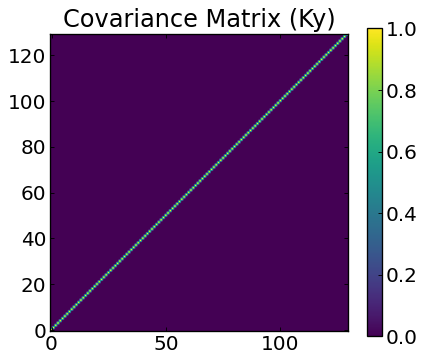

In [8]:
import numpy as np
from scipy.optimize import minimize
import lib_debug

# -------------------- 1. Setup & Aliasing --------------------
kernel = lib_debug.rbf_kernel

# -------------------- 2. Settings --------------------
dims = 2
lower_bounds = [-100, -100]
upper_bounds = [100, 100]

# Initial Gamma
current_gamma = 1.0
noise_std = 0.0
noise_var = noise_std ** 2

n_init = 30
n_iter = 100

# Strategy Selection
STRATEGY = "EI" 
if STRATEGY == "EI":
    acq_func = lib_debug.expected_improvement
    acq_params = {'xi': 0.01}
elif STRATEGY == "LCB":
    acq_func = lib_debug.lower_confidence_bound
    acq_params = {'kappa': 2.0}
else:
    raise ValueError("Unknown strategy")

print(f"--- Strategy Selected: {STRATEGY} ---")

# -------------------- 3. Initialization --------------------
X_train = lib_debug.LHSsampler(dims, n_init, lower_bounds, upper_bounds)
y_train = lib_debug.griewank_2d(X_train).reshape(-1, 1)

# NOTE: No Grid creation here anymore! (We use continuous optimization)

# -------------------- 4. Bayesian Optimization Loop --------------------
print(f"--- Starting Optimization Loop ({n_iter} iterations) ---")
print(f"{'Iter':<5} | {'Best y':<10} | {'New y':<10} | {'Gamma':<8} | {'New x (approx)'}")
print("-" * 75)

for i in range(n_iter):

    # --- Step A: Optimize Hyperparameters (Gamma) ---
    res_hyp = minimize(
        lib_debug.negative_log_marginal_likelihood, 
        x0=[current_gamma], 
        args=(X_train, y_train, noise_var),
        bounds=[(0.1, 100.0)], 
        method='L-BFGS-B'
    )
    if res_hyp.success:
        current_gamma = res_hyp.x[0]

    # --- Step B: Fit GP (Calculate Ky_inv) ---
    Ky_inv = lib_debug.fit_gp(kernel, X_train, current_gamma, noise_var)

    # --- Step C & D: Optimize Acquisition Function (Find Next Point) ---
    # Instead of Grid Search, we use continuous optimization (L-BFGS-B)
    x_new, _ = lib_debug.optimize_acquisition(
        kernel, 
        acq_func, 
        X_train, y_train, Ky_inv, current_gamma, 
        lower_bounds, upper_bounds, acq_params
    )
    
    # --- Step E: Evaluate True Function ---
    y_new = lib_debug.griewank_2d(x_new.reshape(1, -1))

    # --- Step F: Update Data ---
    X_train = np.vstack([X_train, x_new])
    y_train = np.vstack([y_train, y_new])

    # Log
    current_best = np.min(y_train)
    print(f"{i+1:<5} | {current_best:.6f}   | {y_new.item():.6f}   | {current_gamma:.4f}   | [{x_new[0]:.2f}, {x_new[1]:.2f}]")

# -------------------- 5. Final Result & Visualization --------------------
best_idx_final = np.argmin(y_train)
print("-" * 75)
print(f"Optimization Finished.")
print(f"Global Best Found: y = {y_train[best_idx_final].item():.6f}")
print(f"At location: x = {X_train[best_idx_final]}")

# Final Covariance Plot
K_final = kernel(X_train, X_train, current_gamma)
lib_debug.plot_covariance_matrix(K_final)

In [9]:
import numpy as np
from scipy.optimize import minimize
import lib_debug

# -------------------- 1. Setup & Aliasing --------------------
kernel = lib_debug.rbf_kernel

# -------------------- 2. Settings (N-Dimensional) --------------------
dims = 8  #
bound_val = 2.0

# numpy配列で境界を定義 (dimsの数だけ拡張)
lower_bounds = np.full(dims, -bound_val)
upper_bounds = np.full(dims, bound_val)

# Initial Gamma & Noise
current_gamma = 1.0
noise_std = 0.0
noise_var = noise_std ** 2

n_init = 5 * dims  # 次元数に応じて初期点数を増やすのが一般的
n_iter = 100

# Strategy Selection
STRATEGY = "EI" 
if STRATEGY == "EI":
    acq_func = lib_debug.expected_improvement
    acq_params = {'xi': 0.01}
elif STRATEGY == "LCB":
    acq_func = lib_debug.lower_confidence_bound
    acq_params = {'kappa': 2.0}
else:
    raise ValueError("Unknown strategy")

print(f"--- Strategy: {STRATEGY} | Dimensions: {dims} ---")

# -------------------- 3. Initialization --------------------
X_train = lib_debug.LHSsampler(dims, n_init, lower_bounds, upper_bounds)

y_train = lib_debug.ackley_nd(X_train).reshape(-1, 1)

# -------------------- 4. Bayesian Optimization Loop --------------------
print(f"--- Starting Optimization Loop ({n_iter} iterations) ---")
# ログヘッダー調整
print(f"{'Iter':<5} | {'Best y':<10} | {'New y':<10} | {'Gamma':<8} | {'New x vector'}")
print("-" * 90)

for i in range(n_iter):

    # --- Step A: Optimize Hyperparameters (Gamma) ---
    res_hyp = minimize(
        lib_debug.negative_log_marginal_likelihood, 
        x0=[current_gamma], 
        args=(X_train, y_train, noise_var),
        bounds=[(0.1, 100.0)], 
        method='L-BFGS-B'
    )
    if res_hyp.success:
        current_gamma = res_hyp.x[0]

    # --- Step B: Fit GP (Calculate Ky_inv) ---
    Ky_inv = lib_debug.fit_gp(kernel, X_train, current_gamma, noise_var)

    # --- Step C & D: Optimize Acquisition Function ---
    x_new, _ = lib_debug.optimize_acquisition(
        kernel, 
        acq_func, 
        X_train, y_train, Ky_inv, current_gamma, 
        lower_bounds, upper_bounds, acq_params
    )

    # --- Step E: Evaluate True Function (N-D) ---
    y_new = lib_debug.ackley_nd(x_new.reshape(1, -1))

    # --- Step F: Update Data ---
    X_train = np.vstack([X_train, x_new])
    y_train = np.vstack([y_train, y_new])

    # Log
    current_best = np.min(y_train)

    x_str = np.array2string(x_new, precision=2, separator=', ', suppress_small=True)

    print(f"{i+1:<5} | {current_best:.6f}   | {y_new.item():.6f}   | {current_gamma:.4f}   | {x_str}")

# -------------------- 5. Final Result --------------------
best_idx_final = np.argmin(y_train)
print("-" * 90)
print(f"Optimization Finished.")
print(f"Global Best Found: y = {y_train[best_idx_final].item():.6f}")
with np.printoptions(precision=4, suppress=True):
    print(f"At location: x = {X_train[best_idx_final]}")

K_final = kernel(X_train, X_train, current_gamma)
lib_debug.plot_covariance_matrix(K_final)

--- Strategy: EI | Dimensions: 30 ---
--- Starting Optimization Loop (100 iterations) ---
Iter  | Best y     | New y      | Gamma    | New x vector
------------------------------------------------------------------------------------------
1     | 20.292482   | 21.190526   | 1.0000   | [ 31.14, -18.83,  -4.12,   0.04, -31.6 ,   9.82,  30.71,   2.31, -19.25,
  10.79, -13.33, -13.93,  10.88,  25.66, -23.7 , -20.71,  24.37,  24.88,
  21.34,  -3.74,   0.48, -15.15, -31.65, -19.76,  26.76,  -6.05, -11.17,
  19.1 ,  23.6 ,  -8.08]
2     | 20.292482   | 21.395768   | 1.0000   | [ 16.64,  -0.61,  16.16,   1.68, -30.63,   4.61, -25.11,  -9.19,   5.46,
 -21.12,  27.26, -21.28,   4.75, -26.17,  26.9 , -12.8 ,  12.59,  28.48,
 -25.65,  19.81,  -3.64,  31.89,  29.39,  28.94,   2.93,  -3.53,   4.37,
 -23.09, -23.55, -15.  ]
3     | 20.292482   | 21.160603   | 1.0000   | [-17.04,  -2.09, -23.56,   9.97,  -3.33,  24.36, -29.01, -11.57,  31.05,
 -28.95,  16.97,  -5.08,  24.78,  18.64,  26.94,  31.6 ,  -

--- Strategy: EI | Dimensions: 30 ---
--- Starting Optimization Loop (100 iterations) ---
Iter  | Best y     | New y      | Gamma    | New x vector
------------------------------------------------------------------------------------------
1     | 2.446166   | 2.849806   | 1.0000   | [-23.76,   8.11,   0.04,   7.09,   3.72,   3.65, -22.96, -22.39,   0.17,
 -25.04, -20.98,  10.35, -12.99, -10.19,   5.37,  -5.2 , -12.81,  27.33,
  -8.82,  -3.98,  -3.3 ,  -0.48, -11.46,   6.32, -18.09, -13.74, -16.55,
 -29.26,  26.16,  25.35]
2     | 2.446166   | 3.537801   | 1.0000   | [  8.55,  -6.74,  26.12,  17.41, -13.09,  12.33,  -7.05,   9.91, -23.92,
  -1.92, -29.1 , -29.73, -28.55,  29.63,   4.37,  -0.63,  -3.32,  21.03,
 -19.22, -24.56, -31.9 ,  11.71, -21.53,  19.77,   2.02,   1.  ,  -2.57,
 -25.03,  16.28, -14.78]
3     | 2.446166   | 2.983344   | 1.0000   | [ -5.88,  20.33, -12.13,   5.55,  -0.35, -16.03,  -1.47,  10.14, -12.58,
 -21.47,  28.83,  11.48,   8.83,  -7.99,  31.5 ,   7.24, -30.64, 

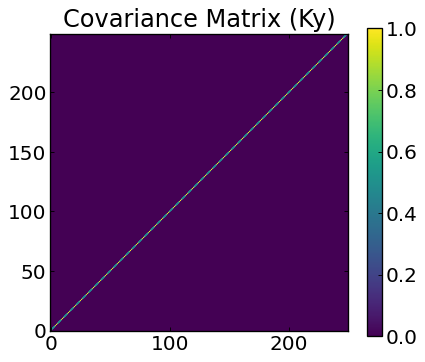

In [ ]:
import numpy as np
from scipy.optimize import minimize
import lib_debug

# -------------------- 1. Setup & Aliasing --------------------
kernel = lib_debug.rbf_kernel

# -------------------- 2. Settings (N-Dimensional) --------------------
dims = 8  #
bound_val = 2.0

# numpy配列で境界を定義 (dimsの数だけ拡張)
lower_bounds = np.full(dims, -bound_val)
upper_bounds = np.full(dims, bound_val)

# Initial Gamma & Noise
current_gamma = 1.0
noise_std = 0.0
noise_var = noise_std ** 2

n_init = 5 * dims  # 次元数に応じて初期点数を増やすのが一般的
n_iter = 100

# Strategy Selection
STRATEGY = "EI" 
if STRATEGY == "EI":
    acq_func = lib_debug.expected_improvement
    acq_params = {'xi': 0.01}
elif STRATEGY == "LCB":
    acq_func = lib_debug.lower_confidence_bound
    acq_params = {'kappa': 2.0}
else:
    raise ValueError("Unknown strategy")

print(f"--- Strategy: {STRATEGY} | Dimensions: {dims} ---")

# -------------------- 3. Initialization --------------------
X_train = lib_debug.LHSsampler(dims, n_init, lower_bounds, upper_bounds)

y_train = lib_debug.griewank_nd(X_train).reshape(-1, 1)

# -------------------- 4. Bayesian Optimization Loop --------------------
print(f"--- Starting Optimization Loop ({n_iter} iterations) ---")
# ログヘッダー調整
print(f"{'Iter':<5} | {'Best y':<10} | {'New y':<10} | {'Gamma':<8} | {'New x vector'}")
print("-" * 90)

for i in range(n_iter):

    # --- Step A: Optimize Hyperparameters (Gamma) ---
    res_hyp = minimize(
        lib_debug.negative_log_marginal_likelihood, 
        x0=[current_gamma], 
        args=(X_train, y_train, noise_var),
        bounds=[(0.1, 100.0)], 
        method='L-BFGS-B'
    )
    if res_hyp.success:
        current_gamma = res_hyp.x[0]

    # --- Step B: Fit GP (Calculate Ky_inv) ---
    Ky_inv = lib_debug.fit_gp(kernel, X_train, current_gamma, noise_var)

    # --- Step C & D: Optimize Acquisition Function ---
    x_new, _ = lib_debug.optimize_acquisition(
        kernel, 
        acq_func, 
        X_train, y_train, Ky_inv, current_gamma, 
        lower_bounds, upper_bounds, acq_params
    )

    # --- Step E: Evaluate True Function (N-D) ---
    y_new = lib_debug.griewank_nd(x_new.reshape(1, -1))

    # --- Step F: Update Data ---
    X_train = np.vstack([X_train, x_new])
    y_train = np.vstack([y_train, y_new])

    # Log
    current_best = np.min(y_train)

    x_str = np.array2string(x_new, precision=2, separator=', ', suppress_small=True)

    print(f"{i+1:<5} | {current_best:.6f}   | {y_new.item():.6f}   | {current_gamma:.4f}   | {x_str}")

# -------------------- 5. Final Result --------------------
best_idx_final = np.argmin(y_train)
print("-" * 90)
print(f"Optimization Finished.")
print(f"Global Best Found: y = {y_train[best_idx_final].item():.6f}")
with np.printoptions(precision=4, suppress=True):
    print(f"At location: x = {X_train[best_idx_final]}")

K_final = kernel(X_train, X_train, current_gamma)
lib_debug.plot_covariance_matrix(K_final)